In [54]:
# autoreload
%load_ext autoreload
%autoreload 2
import os
import anndata
import pickle
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scgenome.plotting as pl

from cellmates.utils.testing import plot_diagnostics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
data_path = '/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results/A3_0/0/'
adata_path = os.path.join(data_path, 'anndata.h5ad')
cm_out_dir = os.path.join(data_path, 'cm_out_rtol1e-4')
diagnostics_path = os.path.join(cm_out_dir, 'em_diagnostics.pkl')

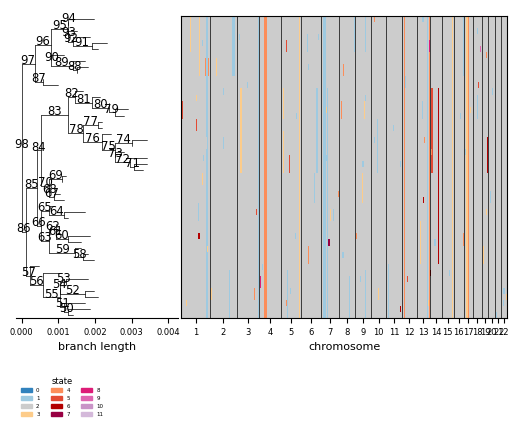

In [115]:
from cellmates.utils.tree_utils import make_gt_tree_dist
from io import StringIO
from Bio import Phylo

# plot data
adata = anndata.read_h5ad(adata_path)
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
# use tree from cn-derived branch lengths
cell_names = adata[~adata.obs['normal']].obs_names.tolist()
dpy_tree, gt_ctr = make_gt_tree_dist(adata, n_states=7, cell_names=cell_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = cell_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick')
# g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree_cn_lengths, raw=True)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree_cn_lengths)


In [116]:
# plot diagnostics
# for every cell pick their max likelihood and plot the diagnostics
diagnostics_data_pairs = pickle.load(open(diagnostics_path, 'rb'))
diagnostics_data_pairs[0, 1]

{'loglikelihoods': [None,
  3704.698061281478,
  3891.7779758485635,
  3892.0331732556756,
  3892.0409430847058,
  3892.041414291922],
 'thetas': [array([0.00028975, 0.00028975, 0.00028975]),
  array([3.38730078e-03, 8.77196570e-06, 4.16254153e-04]),
  array([3.51881979e-03, 4.92550117e-07, 4.05774600e-04]),
  array([3.51549991e-03, 3.01058402e-08, 4.06072314e-04]),
  array([3.51472745e-03, 1.83594693e-09, 4.05746228e-04]),
  array([3.51441367e-03, 1.12032399e-10, 4.05981846e-04])],
 'psis': [array([ 1., 60.,  1., 60.]),
  array([ 0.99809465, 78.54498903,  0.99966038, 75.58616665]),
  array([ 0.99812713, 79.05945045,  0.99969444, 76.15916902]),
  array([ 0.99812846, 79.05838909,  0.99969535, 76.16002066]),
  array([ 0.9981285 , 79.058362  ,  0.99969536, 76.16000592]),
  array([ 0.9981285 , 79.05836261,  0.99969535, 76.1600014 ])]}

In [117]:
import numpy as np

# pick best pairs
n_cells = adata.n_obs
final_lik_pairs = {(s,t): v['loglikelihoods'][-1] for (s,t), v in diagnostics_data_pairs.items()}
max_lik_cell = [-np.inf] * n_cells
max_cellmate = [None] * n_cells
# for each cell find the cell with which max lik is reach and track the likelihood
for (s, t), v in final_lik_pairs.items():
    if v > max_lik_cell[s]:
        max_lik_cell[s] = v
        max_cellmate[s] = t
    if v > max_lik_cell[t]:
        max_lik_cell[t] = v
        max_cellmate[t] = s

In [118]:
for s, t in enumerate(max_cellmate):
    s, t = min(s, t), max(s, t)
    g = plot_diagnostics(diagnostics_data_pairs[s,t], cm_out_dir, prefix=f'{s}-{t}')

In [119]:
diagnostics_data_pairs[0,1]

{'loglikelihoods': [None,
  3704.698061281478,
  3891.7779758485635,
  3892.0331732556756,
  3892.0409430847058,
  3892.041414291922],
 'thetas': [array([0.00028975, 0.00028975, 0.00028975]),
  array([3.38730078e-03, 8.77196570e-06, 4.16254153e-04]),
  array([3.51881979e-03, 4.92550117e-07, 4.05774600e-04]),
  array([3.51549991e-03, 3.01058402e-08, 4.06072314e-04]),
  array([3.51472745e-03, 1.83594693e-09, 4.05746228e-04]),
  array([3.51441367e-03, 1.12032399e-10, 4.05981846e-04])],
 'psis': [array([ 1., 60.,  1., 60.]),
  array([ 0.99809465, 78.54498903,  0.99966038, 75.58616665]),
  array([ 0.99812713, 79.05945045,  0.99969444, 76.15916902]),
  array([ 0.99812846, 79.05838909,  0.99969535, 76.16002066]),
  array([ 0.9981285 , 79.058362  ,  0.99969536, 76.16000592]),
  array([ 0.9981285 , 79.05836261,  0.99969535, 76.1600014 ])]}

## Convergence speed
Tolerance for stopping is set to 10e-5, but it's likely that we can halve the number of iterations just by setting it to 10e-4

In [120]:
# convergence speed
# plot the value of likelihood improvement over iterations
# add to dataset for plotting
rows = []
eps_zero = 1e-10
for pi, pair in enumerate(diagnostics_data_pairs):
    prev_ll = None
    for it in range(1, len(diagnostics_data_pairs[pair]['loglikelihoods'])):
        # first iteration is always none
        ll = diagnostics_data_pairs[pair]['loglikelihoods'][it]
        if prev_ll is not None:
            rel_delta = (ll - prev_ll) / (np.abs(ll) + eps_zero)
            rows.append([pi, it, rel_delta])
        prev_ll = ll

convergence_df = pd.DataFrame(rows, columns=['pi', 'it', 'rel_delta'])
convergence_df.head()


,pi,it,rel_delta
0,0,2,4.303249e-02
1,0,3,2.971278e-05
2,0,4,-1.063920e-07
3,0,5,6.333657e-09
4,1,2,4.745338e-02


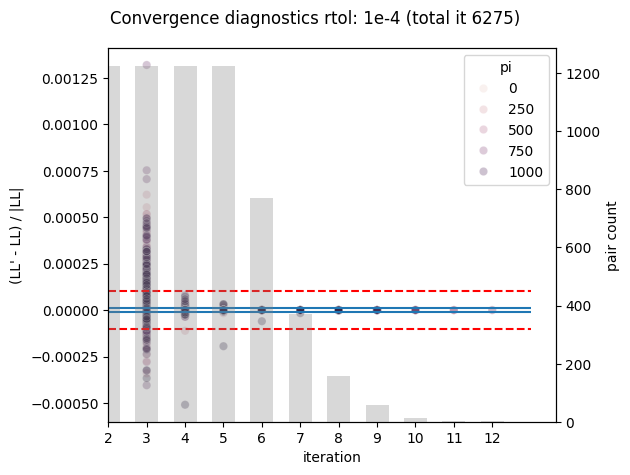

In [121]:
rtol_threshold = 1e-5
rtol_high = 1e-4
fig, ax1 = plt.subplots()

# scatter plot
sns.scatterplot(data=convergence_df[convergence_df['it'] > 2], x='it', y='rel_delta', hue='pi', ax=ax1, alpha=0.3)
ax1.hlines([rtol_threshold, -rtol_threshold], 0, convergence_df['it'].max() + 1, label='1e-5')
ax1.hlines([rtol_high, -rtol_high], 0, convergence_df['it'].max() + 1, linestyles='dashed', colors='red')
ax1.set_xticks(range(2, convergence_df['it'].max() + 1))
ax1.set_xlim(left=2)
ax1.set_xlabel('iteration')
ax1.set_ylabel("(LL' - LL) / |LL|")

# bar plot of unique pi counts per iteration
ax2 = ax1.twinx()
counts = convergence_df.groupby('it')['pi'].nunique()
ax2.bar(counts.index, counts.values, alpha=0.3, color='gray', width=0.6)
ax2.set_ylabel('pair count')
fig.suptitle(f'Convergence diagnostics rtol: 1e-4 (total it {convergence_df.shape[0]})')
fig.tight_layout()

## Euclidean distance vs Median to root distance

In [31]:
def heatmap(matrix):
    """
    matrix: (n_cells, n_cells)
    """
    plt.matshow(matrix, cmap=plt.cm.Blues)
    plt.colorbar()

def euclidean_distance_matrix(a):
    """
    mat: (n_cells, n_bins)
    Returns: (n_cells, n_cells)
    """
    b = a.reshape(a.shape[0], 1, a.shape[1])
    return np.sqrt(np.einsum('ijk, ijk->ij', a-b, a-b))

def simple_normalize(a):
    res = (a - a.min()) / (a.max() - a.min())
    return res

In [10]:
euc_dist = euclidean_distance_matrix(adata.layers['copy'])
euc_dist.shape

(10, 10)

In [39]:
em_dist = np.load(os.path.join(cm_out_dir, 'distance_matrix.npy'))
ltm_dist = em_dist[:, :, 1] + em_dist[:, :, 2]  # leaf to median distance
np.fill_diagonal(ltm_dist, 0)
ltm_dist[np.tril_indices_from(ltm_dist)] = ltm_dist.T[np.tril_indices_from(ltm_dist)]

mtr_dist = em_dist[:, :, 0]
np.fill_diagonal(mtr_dist, 0)
# copy triu elements into tril matrix (mirrored)
mtr_dist[np.tril_indices_from(mtr_dist)] = mtr_dist.T[np.tril_indices_from(mtr_dist)]
mtr_dist.shape

(10, 10)

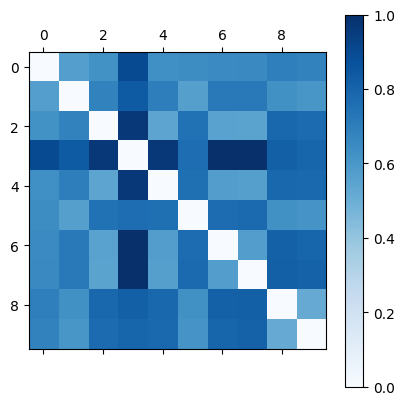

In [40]:
heatmap(simple_normalize(euc_dist))

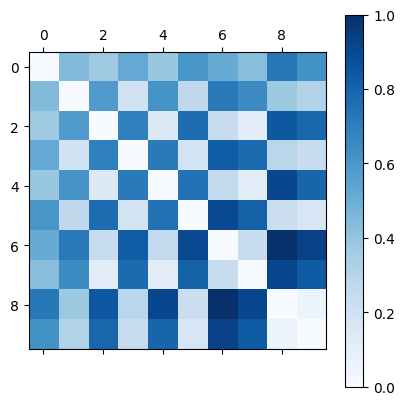

In [41]:
heatmap(simple_normalize(ltm_dist))

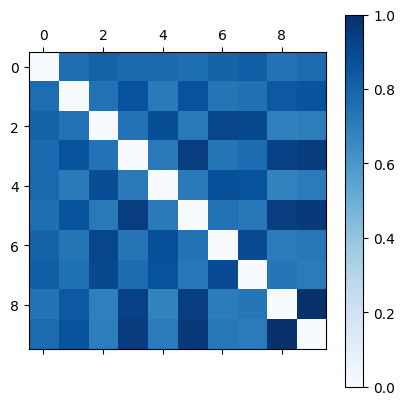

In [42]:
heatmap(simple_normalize(mtr_dist))

In [22]:
mtr_dist

array([[ 0.        ,  0.00263807,  0.00278455,  0.00267598,  0.00271385,
         0.00261201,  0.00277985,  0.00284284,  0.00256215,  0.00266371],
       [-1.        ,  0.        ,  0.00256768,  0.0030128 ,  0.00246001,
         0.00299793,  0.00253926,  0.00257965,  0.00291853,  0.00298787],
       [-1.        , -1.        ,  0.        ,  0.00257768,  0.00305206,
         0.00247433,  0.00315819,  0.00312439,  0.00240105,  0.00242599],
       [-1.        , -1.        , -1.        ,  0.        ,  0.00246037,
         0.00325893,  0.00252352,  0.00265341,  0.00322115,  0.00328134],
       [-1.        , -1.        , -1.        , -1.        ,  0.        ,
         0.002464  ,  0.00304704,  0.00301099,  0.00234729,  0.0024552 ],
       [-1.        , -1.        , -1.        , -1.        , -1.        ,
         0.        ,  0.00257162,  0.00250033,  0.00326195,  0.00332636],
       [-1.        , -1.        , -1.        , -1.        , -1.        ,
        -1.        ,  0.        ,  0.00308995